# Part 1

In [1]:
!which pip

/home/sai/.cache/uv/builds-v0/.tmp5pD50O/bin/pip


In [2]:
!pip list

Package                   Version
------------------------- -----------
anyio                     4.13.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.7
comm                      0.2.3
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.21.2
fqdn                      1.5.1
h11                       0.16.0
httpcore                  1.0.9
httpx                     0.28.1
idna                      3.11
ImageIO                   2.37.3
ipykernel                 7.2.0
ipython                   9.12.0
ipython_pygments_lexers   1.1.1
ipywidgets       

In [3]:
# Install all dependencies
%pip install matplotlib scikit-image numpy Pillow

  Using cached matplotlib-3.10.8-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (5.0 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.w

In [18]:
# Packages
import os
import glob
import cv2 as cv
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv
import numpy as np
from PIL import Image

In [5]:
# Load the datasets

# change path according to where u put the folder
path = "filtered_img"
images_path = glob.glob(os.path.join(path, "*.jpg"))

print("Number of images:", len(images_path))


Number of images: 5


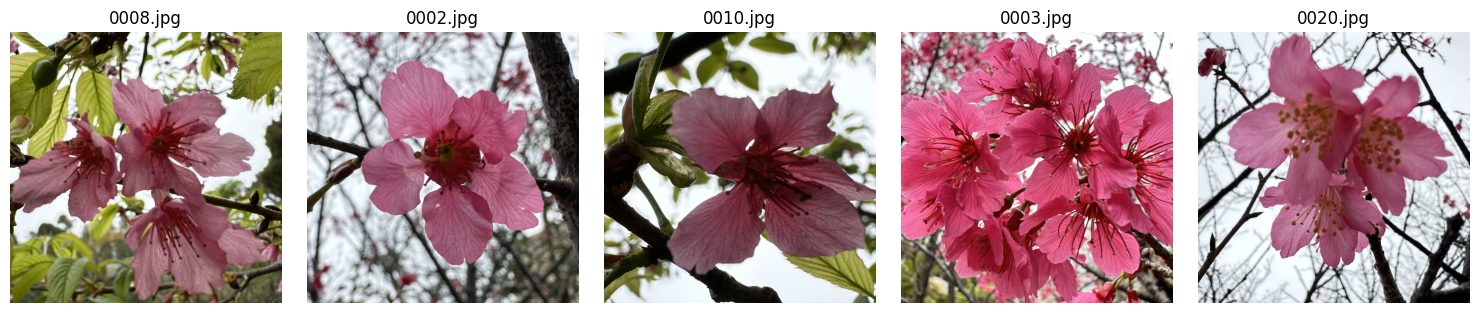

In [6]:
# Show all images first

plt.figure(figsize=(15, 6)) 

for i, file in enumerate(images_path):
    img = Image.open(file)
    plt.subplot(2, 5, i+1)  
    plt.imshow(img)
    plt.axis("off")
    plt.title(os.path.basename(file))

plt.tight_layout()
plt.show()

In [7]:
# Open them as PIL images
images = [Image.open(file) for file in images_path]

In [8]:
# Function that reshapes the images to (100,100,3)
def image_reshape(img):
    img = img.convert("RGB")
    img = img.resize((100, 100))
    return np.array(img)

In [9]:
# Reshape all
reshaped_img = [image_reshape(img) for img in images]
print("Shape of first reshaped image:", reshaped_img[0].shape)

Shape of first reshaped image: (100, 100, 3)


In [10]:
# Save all of the images in another directory

output_path = "reshaped_dataset"
os.makedirs(output_path, exist_ok=True)

for i, arr in enumerate(reshaped_img):
    img = Image.fromarray(arr)  # convert NumPy array back to PIL
    save_path = os.path.join(output_path, f"flower_{i+1}.jpg")
    img.save(save_path, "JPEG")

print(f"Saved {len(reshaped_img)} images to '{output_path}'")

Saved 5 images to 'reshaped_dataset'


In [11]:
# Separate RGB channels

img_data = np.stack(reshaped_img)

red = img_data[:,:,:,0].ravel()
green = img_data[:,:,:,1].ravel()
blue = img_data[:,:,:,2].ravel()

In [12]:
# Normalize img_data
rgb_norm = img_data / 255.0
hsv = rgb2hsv(rgb_norm)

In [13]:
# Separate hues, saturation, and intensities

hues        = hsv[:,:,:,0].ravel()       
saturations = hsv[:,:,:,1].ravel()        
intensities = hsv[:,:,:,2].ravel()

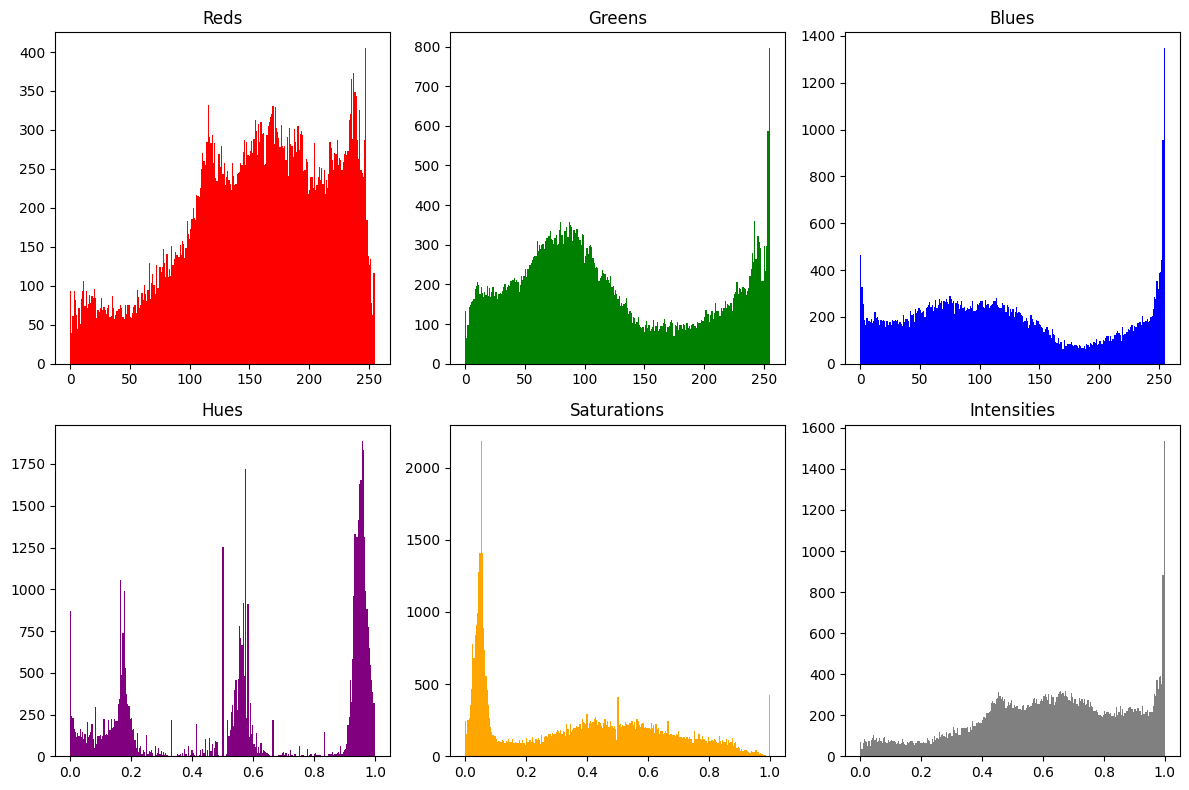

In [14]:
#Plot the histogram

plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.hist(red, bins=256, color='red')
plt.title("Reds")

plt.subplot(2,3,2)
plt.hist(green, bins=256, color='green')
plt.title("Greens")

plt.subplot(2,3,3)
plt.hist(blue, bins=256, color='blue')
plt.title("Blues")

plt.subplot(2,3,4)
plt.hist(hues, bins=256, color='purple')
plt.title("Hues")

plt.subplot(2,3,5)
plt.hist(saturations, bins=256, color='orange')
plt.title("Saturations")

plt.subplot(2,3,6)
plt.hist(intensities, bins=256, color='gray')
plt.title("Intensities")

plt.tight_layout()
plt.show()


# Part 3

While waiting for part 2 a separate folder after filtering out images that are taken during night and not pink flowers

- Adjusts the exposure of the images based on the brightest image. (Hint: You may manually select the representative image and apply Gamma Correction)
- Adjusts the saturation of the images to match the saturation of the most saturated image. (Hint: You may manually select the representative image and apply Histogram Equalization and Channel Arithmetic)

In [15]:
def adjust_gamma(image, gamma=1.0):
    invGamma = 1.0 / (gamma+1e-06)
    table = np.array([((i / 255.0) ** invGamma) * 255
        for i in np.arange(0, 256)]).astype("uint8")
    return cv.LUT(image, table)

In [16]:
dir = "reshaped_dataset"

In [21]:
# https://www.geeksforgeeks.org/python/how-to-iterate-over-files-in-directory-using-python/

directory = 'reshaped_dataset'
WIDTH = 100
HEIGHT = 100
# if not os.path.isdir(new_dir):
#     print('creating new dir')
#     os.mkdir(new_dir)
    
i = 0
for entry in os.scandir(directory):
    if entry.is_file():
        print(entry.path)
        img = cv.imread(entry.path)
        img_hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
        # h,s,v = img_hsv
        print(img_hsv)
        i += 1

reshaped_dataset/flower_5.jpg
[[[113  12 249]
  [113  14 218]
  [125  14 194]
  ...
  [111  14 235]
  [111  14 235]
  [111  14 235]]

 [[111  14 230]
  [111  13 254]
  [113  14 213]
  ...
  [111  14 235]
  [111  14 235]
  [111  14 235]]

 [[ 98  15 247]
  [ 98  16 236]
  [104  16 208]
  ...
  [111  14 236]
  [111  14 236]
  [111  14 236]]

 ...

 [[101   8 249]
  [101  10 205]
  [101  19 108]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   1]]

 [[101  10 204]
  [101  12 174]
  [101  19 106]
  ...
  [  0   0   0]
  [  0   0   1]
  [  0   0   5]]

 [[101  11 178]
  [101  10 197]
  [101  13 159]
  ...
  [  0   0   0]
  [  0   0   3]
  [  0   0  11]]]
reshaped_dataset/flower_4.jpg
[[[172  42 188]
  [167  19 255]
  [169  27 255]
  ...
  [  0   0 255]
  [  0   0 253]
  [  0   0 249]]

 [[172  38 182]
  [172  36 193]
  [170  27 254]
  ...
  [  0   0 248]
  [  0   0 244]
  [  0   0 253]]

 [[178  25 165]
  [177  22 223]
  [160   6 255]
  ...
  [  0   0 251]
  [  0   0 251]
  [  0   0 255]]